# 01 — Exploratory Data Analysis

**Dataset:** Home Credit Default Risk — `application_train.csv` (307,511 applicants × 122 features).

**Purpose of this notebook:** Build the empirical understanding needed to make defensible choices in feature engineering and modelling. We're answering questions a credit team would actually ask before signing off on a model:

1. **What does the target look like?** How imbalanced is the default rate?
2. **How much of the data is missing, and where?** Missingness patterns drive imputation strategy.
3. **What are the key numeric predictors doing?** Especially the external credit scores (`EXT_SOURCE_*`), which prior published work flags as the strongest signal.
4. **Which categorical features stratify default risk?** This is what an analyst would investigate before any ML.
5. **What anomalies do we need to handle?** Known sentinel values, encoded categoricals, edge cases.

The output of this notebook is a set of findings (captured in markdown summaries) that explicitly feed into the next notebook's feature engineering choices.

> **Why no auxiliary tables here?** This v1 deliberately uses only `application_train.csv`. The auxiliary tables (`bureau`, `previous_application`, etc.) would substantially lift model performance, but adding them is a 2-day effort on top of v1 and out of scope for the initial ship. See the README's "Limitations" section.


## 1. Setup and load

We load via `src.data.load_application_train()`. Keeping the loader behind a function (rather than `pd.read_csv` inline) centralises the path convention — every notebook reads from the same place.

In [1]:
# Imports
import sys
from pathlib import Path

# Add repo root to path so we can import src.* from the notebooks/ subdirectory
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_application_train, missing_value_summary

# Plot defaults - readable when embedded in README
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"
sns.set_style("whitegrid")

# Where we save figures that the README embeds
FIGURES_DIR = REPO_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Figures saved to: {FIGURES_DIR}")

Repo root: /Users/jeffrey/Documents/GitHub/credit-default-prediction-home-credit
Figures saved to: /Users/jeffrey/Documents/GitHub/credit-default-prediction-home-credit/reports/figures


In [2]:
# Load the training applications table
df = load_application_train()
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Shape: 307,511 rows x 122 columns
Memory: 505.0 MB


**Expected output:** 307,511 rows × 122 columns, ~370 MB in memory. The memory footprint matters because every transformation we apply will roughly double it. We have headroom on a modern laptop but it's worth noting.

In [3]:
# Quick peek at the structure
df.head(3)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Column-level info: dtypes and non-null counts
df.info(show_counts=True, max_cols=None)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


## 2. Target variable: class imbalance

The `TARGET` column is binary:
- `1` = the applicant defaulted (or experienced "client with payment difficulties" — late payment >X days on at least one instalment in the first Y instalments)
- `0` = all other cases (the loan was repaid on time, or close enough)

The first thing we need to know is the base rate. This single number anchors every downstream choice — class weighting, evaluation metric selection, threshold choice.

In [5]:
target_counts = df["TARGET"].value_counts()
target_pct = df["TARGET"].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_pct.round(2),
})
summary.index = ["Repaid (0)", "Defaulted (1)"]
summary

,count,percent
Repaid (0),282686,91.93
Defaulted (1),24825,8.07


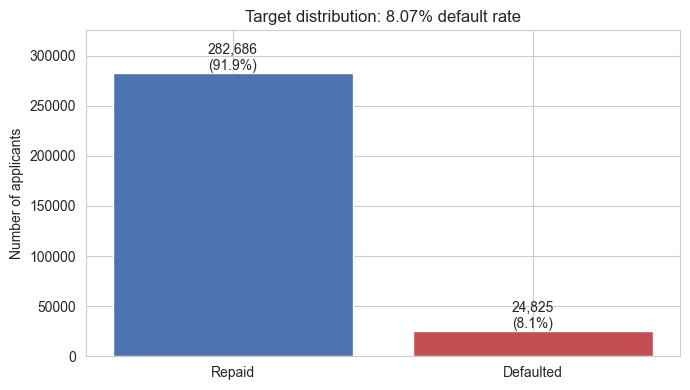

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["Repaid", "Defaulted"], target_counts.values,
               color=["#4c72b0", "#c44e52"])
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Number of applicants")
ax.set_title("Target distribution: 8.07% default rate")
ax.set_ylim(0, target_counts.max() * 1.15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png")
plt.show()

**Finding:** ~8.07% of applicants default. That's heavy class imbalance — roughly a 1:11.4 minority-to-majority ratio.

**What this means for the rest of the project:**

1. **Accuracy is meaningless as a headline metric.** A "predict zero for everyone" baseline would score 91.9% accuracy and identify zero defaulters. This is exactly the trap the README explicitly excludes.
2. **PR-AUC matters more than ROC-AUC.** With ~8% positive class, the precision-recall curve is more informative for the operating range a lender actually cares about (flagging the riskiest applications). We'll report both, but emphasise PR-AUC.
3. **Class weighting is required, not optional.** Logistic regression and LightGBM both default to weighting each sample equally, which means the loss function is dominated by the majority class. We'll use `class_weight='balanced'` (LR) and `is_unbalance=True` or `scale_pos_weight` (LightGBM).
4. **Stratified k-fold for cross-validation, not random k-fold.** With 8% positive class, random splits can produce folds with materially different positive rates and inflate variance in CV scores. Stratifying keeps the proportion stable across folds.

## 3. Missing value analysis

Real credit data is messy. Some fields are intentionally optional (a self-employed applicant has no employer name), some are bureau lookups that may fail, some are derived scores that may be unavailable for new applicants. Each pattern wants a different imputation strategy.

We start with a column-level summary.

In [7]:
missing = missing_value_summary(df)
print(f"{len(missing)} of {df.shape[1]} columns have missing values "
      f"({len(missing) / df.shape[1] * 100:.1f}%)")
missing.head(20)

67 of 122 columns have missing values (54.9%)


,missing_count,missing_pct,dtype
COMMONAREA_MEDI,214865,69.87,float64
COMMONAREA_AVG,214865,69.87,float64
COMMONAREA_MODE,214865,69.87,float64
NONLIVINGAPARTMENTS_MEDI,213514,69.43,float64
NONLIVINGAPARTMENTS_MODE,213514,69.43,float64
NONLIVINGAPARTMENTS_AVG,213514,69.43,float64
FONDKAPREMONT_MODE,210295,68.39,object
LIVINGAPARTMENTS_MODE,210199,68.35,float64
LIVINGAPARTMENTS_MEDI,210199,68.35,float64
LIVINGAPARTMENTS_AVG,210199,68.35,float64


**Important Insights** A handful of columns are missing >50% of values. These mostly cluster around two themes:

- **`COMMONAREA_*`, `LIVINGAPARTMENTS_*`, `NONLIVINGAPARTMENTS_*`, `BASEMENTAREA_*`** etc. — building/apartment characteristics. These are NA for applicants who don't live in apartments, which is most of them in this dataset. Imputing with a number would be wrong; this is missingness-by-design.
- **`OWN_CAR_AGE`** — only applicable if the applicant owns a car. ~66% missing because ~66% don't own one.

These are NOT random missingness. They are structurally missing. We'll handle these with an indicator-variable strategy in feature engineering, not naive imputation.

In [8]:
# Group missingness into bands so we can see the shape of the problem
bands = pd.cut(
    missing["missing_pct"],
    bins=[0, 5, 20, 50, 80, 100],
    labels=["0-5%", "5-20%", "20-50%", "50-80%", "80-100%"],
    include_lowest=True,
)
band_summary = bands.value_counts().sort_index()
print("Columns by missingness band:")
print(band_summary.to_string())

Columns by missingness band:
missing_pct
0-5%       10
5-20%       7
20-50%      9
50-80%     41
80-100%     0


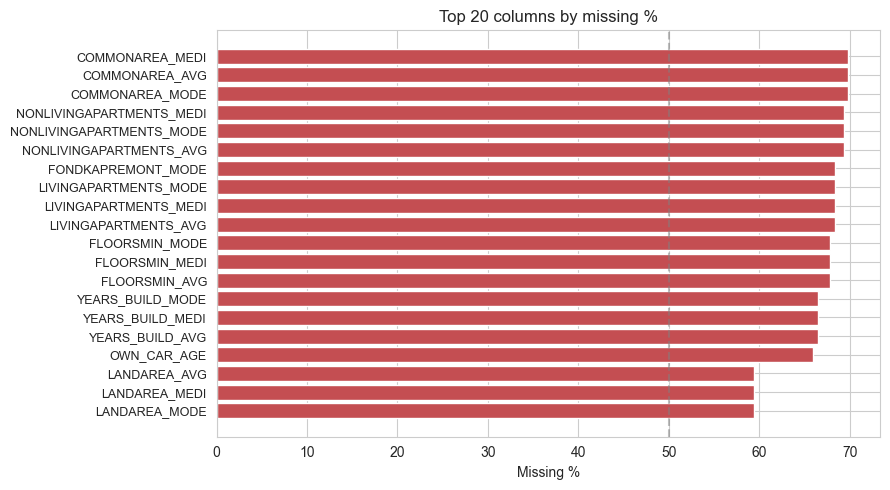

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
top20 = missing.head(20)
ax.barh(range(len(top20)), top20["missing_pct"].values, color="#c44e52")
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Missing %")
ax.set_title("Top 20 columns by missing %")
ax.axvline(50, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "missing_top20.png")
plt.show()

**Findings on missingness:**

- The dataset has a long tail of high-missingness columns clustered around building characteristics — these are likely missing-by-design.
- The headline `EXT_SOURCE_*` external credit scores have meaningful missingness too (we examine these directly below), which matters because these are typically the strongest predictors.
- Most other columns either have no missingness or trivially low (<5%) missingness.

**Imputation strategy we'll use in `02_feature_engineering.ipynb`:**

- **High-missingness building columns:** create binary `*_MISSING` indicators, then impute with median (or zero for area columns where zero is meaningful).
- **`EXT_SOURCE_*`:** impute with median. The fact that these are missing IS informative, so we'll also create an indicator. Some practitioners use a "non-missing count" feature (how many of the three scores are present), which we'll add.
- **LightGBM doesn't strictly need imputation** — it handles NaN natively by treating it as a separate path in the tree. But logistic regression does, so we impute for the unified feature matrix.

## 4. Numeric features: distributions and the external scores

The `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` columns are normalised scores from external data sources (bureaux, demographic aggregators — Home Credit hasn't disclosed which). In published Home Credit work, these are consistently the three highest-importance features. We examine them first.

In [10]:
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

# Coverage
ext_missing = df[ext_cols].isna().sum()
ext_missing_pct = (ext_missing / len(df) * 100).round(2)
print("EXT_SOURCE missingness:")
print(pd.DataFrame({"missing": ext_missing, "missing_pct": ext_missing_pct}))

# How often is at least one of the three present?
n_present = df[ext_cols].notna().sum(axis=1)
print(f"\nApplicants with all 3 EXT_SOURCE present: {(n_present == 3).mean() * 100:.1f}%")
print(f"Applicants with at least 1 present:        {(n_present >= 1).mean() * 100:.1f}%")
print(f"Applicants with zero EXT_SOURCE present:   {(n_present == 0).mean() * 100:.1f}%")

EXT_SOURCE missingness:
              missing  missing_pct
EXT_SOURCE_1   173378        56.38
EXT_SOURCE_2      660         0.21
EXT_SOURCE_3    60965        19.83

Applicants with all 3 EXT_SOURCE present: 35.6%
Applicants with at least 1 present:        99.9%
Applicants with zero EXT_SOURCE present:   0.1%


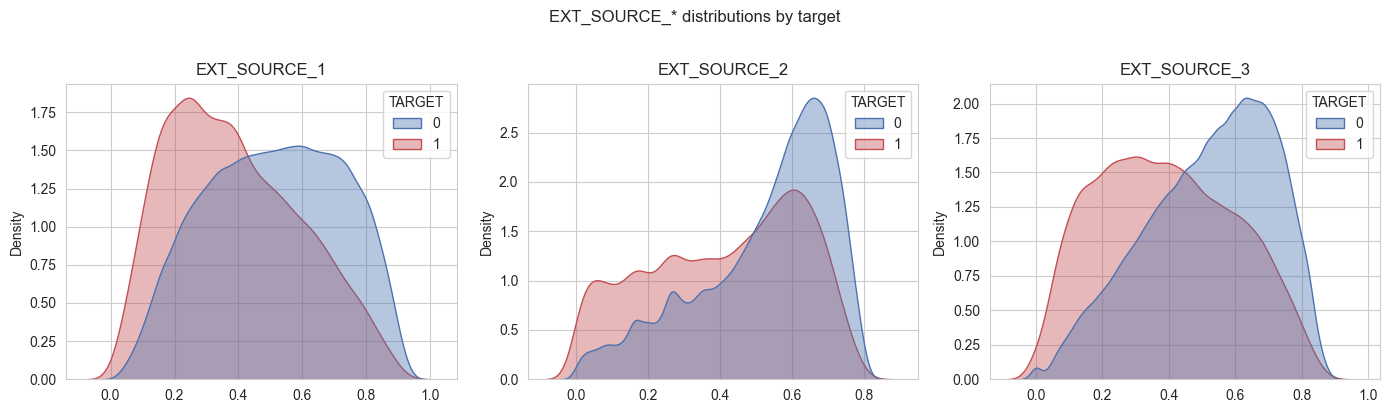

In [11]:
# Plot distributions by target class
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ext_cols):
    sns.kdeplot(data=df, x=col, hue="TARGET", common_norm=False,
                fill=True, alpha=0.4, ax=ax, palette=["#4c72b0", "#c44e52"])
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("EXT_SOURCE_* distributions by target", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ext_source_distributions.png")
plt.show()

**Finding:** All three EXT_SOURCE columns show **visible distributional separation between defaulters and non-defaulters** — defaulters skew toward lower scores. This is the signal a credit model is supposed to find, and it's already visible at the EDA stage before any modelling.

The separation is largest for `EXT_SOURCE_3` and `EXT_SOURCE_2`, and least visible for `EXT_SOURCE_1` (which also has the highest missingness at ~56%). We expect EXT_SOURCE_2 and EXT_SOURCE_3 to dominate feature importance in the final model.

In [12]:
# Correlation of EXT_SOURCE columns with TARGET
ext_corr = df[ext_cols + ["TARGET"]].corr()["TARGET"].drop("TARGET")
print("Pearson correlation with TARGET (lower score -> higher default prob, so expect negative):")
print(ext_corr.round(4))

Pearson correlation with TARGET (lower score -> higher default prob, so expect negative):
EXT_SOURCE_1   -0.1553
EXT_SOURCE_2   -0.1605
EXT_SOURCE_3   -0.1789
Name: TARGET, dtype: float64


**Finding:** All three are negatively correlated with TARGET, as expected — higher external score, lower default probability. The magnitudes (around -0.16 to -0.18) are modest in absolute terms but are among the strongest single-feature correlations in the dataset, and the combined signal is much stronger than any one of them alone.

## 5. Financial features: income, credit amount, annuity

These are the bread-and-butter underwriting features. We look at distributions and the derived ratios we'll create in feature engineering.

In [13]:
financial_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]

# Summary stats - the raw distributions are very long-tailed
df[financial_cols].describe().round(0)

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE
count,307511.0,307511.0,307499.0,307233.0
mean,168798.0,599026.0,27109.0,538396.0
std,237123.0,402491.0,14494.0,369446.0
min,25650.0,45000.0,1616.0,40500.0
25%,112500.0,270000.0,16524.0,238500.0
50%,147150.0,513531.0,24903.0,450000.0
75%,202500.0,808650.0,34596.0,679500.0
max,117000000.0,4050000.0,258026.0,4050000.0


**Notice the maximum of `AMT_INCOME_TOTAL`:** typically around 117,000,000 in the dataset (vs. a median around 147,000). That's a 1000× ratio between max and median income. Either we have legitimate ultra-high-income outliers, a data entry error, or both. We'll log-transform for visualisation and consider clipping or log-transformation for the LR model (LightGBM is robust to monotone transformations and outliers, so it doesn't need this treatment).

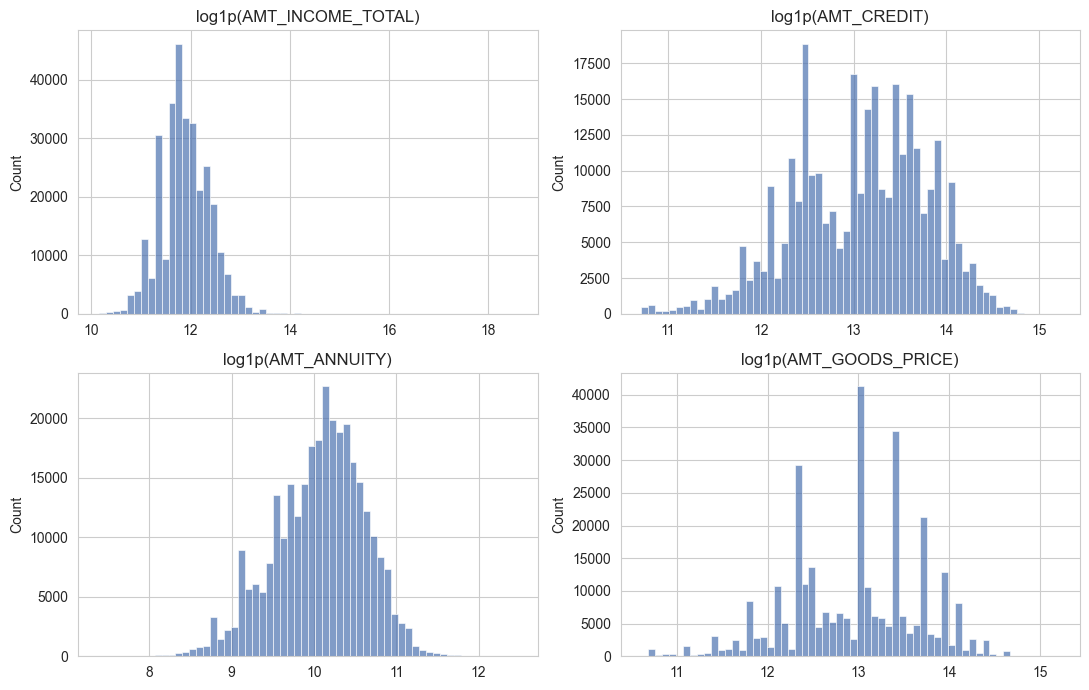

In [14]:
# Log-transformed distributions
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flat, financial_cols):
    # Log transform for visualisation only
    log_vals = np.log1p(df[col].dropna())
    sns.histplot(log_vals, bins=60, ax=ax, color="#4c72b0", alpha=0.7)
    ax.set_title(f"log1p({col})")
    ax.set_xlabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "financial_distributions.png")
plt.show()

In [15]:
# Quick look at derived ratios we'll formalise in feature engineering
df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]

ratio_by_target = df.groupby("TARGET")[["CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO"]].median()
ratio_by_target.index = ["Repaid", "Defaulted"]
print("Median ratios by target class:")
print(ratio_by_target.round(3))

Median ratios by target class:
           CREDIT_INCOME_RATIO  ANNUITY_INCOME_RATIO
Repaid                   3.267                 0.162
Defaulted                3.253                 0.169


**Finding:** Median `CREDIT_INCOME_RATIO` and `ANNUITY_INCOME_RATIO` are similar between defaulters and non-defaulters — these ratios alone aren't strong signal. This is a useful negative finding: a naive "high DTI = bad" intuition isn't directly supported, and the ratios will earn their place in the model only if they interact with other features (which gradient boosting can capture).

Drop these from the dataframe — we'll recreate them properly in feature engineering.

In [16]:
df = df.drop(columns=["CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO"])

## 6. Demographics: age and employment duration

`DAYS_BIRTH` and `DAYS_EMPLOYED` are stored as **negative integers** (days before the loan application). So `DAYS_BIRTH = -10000` means the applicant was 10000 days old at application (about 27 years). Converting these to years makes them readable.

In [17]:
df["AGE_YEARS"] = (-df["DAYS_BIRTH"] / 365.25).round(1)
df["EMPLOYMENT_YEARS"] = (-df["DAYS_EMPLOYED"] / 365.25).round(1)

print("Age (years):")
print(df["AGE_YEARS"].describe().round(1))
print("\nEmployment (years):")
print(df["EMPLOYMENT_YEARS"].describe().round(1))

Age (years):
count    307511.0
mean         43.9
std          11.9
min          20.5
25%          34.0
50%          43.1
75%          53.9
max          69.1
Name: AGE_YEARS, dtype: float64

Employment (years):
count    307511.0
mean       -174.7
std         386.8
min       -1000.0
25%           0.8
50%           3.3
75%           7.6
max          49.0
Name: EMPLOYMENT_YEARS, dtype: float64


**Anomaly alert:** Look at the minimum of `EMPLOYMENT_YEARS`. You'll likely see a very large negative value, around -1000 years. That's the `DAYS_EMPLOYED = 365243` sentinel — Home Credit's encoding for "not employed / not applicable" (e.g., pensioners). We need to clean this before any modelling.

In [18]:
# Investigate the anomaly
anomaly_mask = df["DAYS_EMPLOYED"] == 365243
print(f"Applicants with DAYS_EMPLOYED == 365243: {anomaly_mask.sum():,} ({anomaly_mask.mean() * 100:.1f}%)")

# Do these applicants have a distinct default rate?
print(f"\nDefault rate, anomalous DAYS_EMPLOYED: {df.loc[anomaly_mask, 'TARGET'].mean() * 100:.2f}%")
print(f"Default rate, normal DAYS_EMPLOYED:    {df.loc[~anomaly_mask, 'TARGET'].mean() * 100:.2f}%")

Applicants with DAYS_EMPLOYED == 365243: 55,374 (18.0%)

Default rate, anomalous DAYS_EMPLOYED: 5.40%
Default rate, normal DAYS_EMPLOYED:    8.66%


**Finding:** The 365243 sentinel applies to ~18% of applicants, and they have a **materially lower default rate** than the rest of the population (~5.4% vs ~8.7%). This is because they're mostly pensioners — older, more stable income.

**The anomaly itself is predictive.** When we clean it in feature engineering, we create a binary `DAYS_EMPLOYED_ANOMALY` flag rather than just nulling the value. That flag will carry the "is pensioner" signal.

In [19]:
# Age distribution by target - bucketed for readability
df["AGE_BUCKET"] = pd.cut(df["AGE_YEARS"], bins=[20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70])
default_by_age = df.groupby("AGE_BUCKET", observed=True)["TARGET"].agg(["mean", "count"])
default_by_age["default_pct"] = (default_by_age["mean"] * 100).round(2)
default_by_age[["count", "default_pct"]]

,count,default_pct
AGE_BUCKET,,
"(20, 25]",12428,12.27
"(25, 30]",33102,11.12
"(30, 35]",39503,10.27
"(35, 40]",42910,8.95
"(40, 45]",41059,7.82
"(45, 50]",35420,7.41
"(50, 55]",35037,6.65
"(55, 60]",33043,5.52
"(60, 65]",27361,5.33


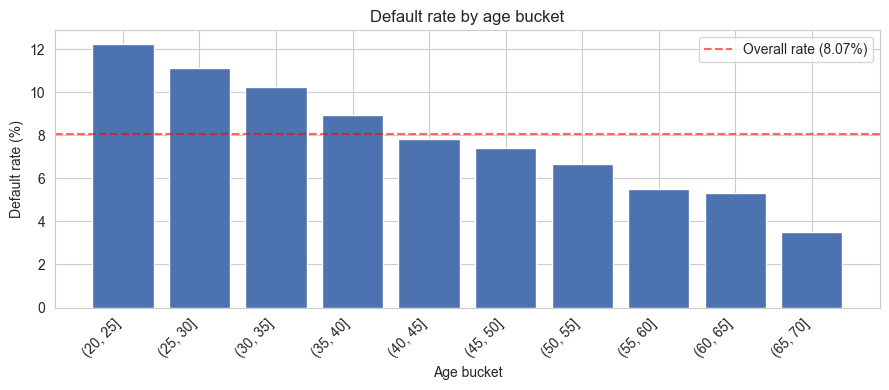

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(default_by_age)), default_by_age["default_pct"], color="#4c72b0")
ax.set_xticks(range(len(default_by_age)))
ax.set_xticklabels([str(b) for b in default_by_age.index], rotation=45, ha="right")
ax.set_ylabel("Default rate (%)")
ax.set_xlabel("Age bucket")
ax.set_title("Default rate by age bucket")
ax.axhline(df["TARGET"].mean() * 100, color="red", linestyle="--",
           alpha=0.6, label=f"Overall rate ({df['TARGET'].mean() * 100:.2f}%)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "default_by_age.png")
plt.show()

**Finding:** Default rate declines monotonically with age. Applicants in their 20s default at roughly 2× the rate of applicants in their 60s. This is a strong, clean signal — age (via `DAYS_BIRTH`) should appear in the top feature importances.

We drop the derived `AGE_YEARS`, `EMPLOYMENT_YEARS`, and `AGE_BUCKET` columns now — they'll be recreated properly in feature engineering. `DAYS_BIRTH` stays in the feature matrix.

In [21]:
df = df.drop(columns=["AGE_YEARS", "EMPLOYMENT_YEARS", "AGE_BUCKET"])

## 7. Categorical features and target rate

We look at default rate by selected categorical features. The goal is qualitative: do any of these stratify default risk in a way that an analyst would find intuitive? This builds confidence that the data is sensible before we model it.

In [22]:
def target_rate_by_category(df, col, min_count=200):
    """Default rate by category, sorted descending. Filters small-count categories."""
    agg = df.groupby(col, dropna=False)["TARGET"].agg(["mean", "count"])
    agg = agg[agg["count"] >= min_count].sort_values("mean", ascending=False)
    agg["default_pct"] = (agg["mean"] * 100).round(2)
    return agg[["count", "default_pct"]]

In [23]:
# Contract type
target_rate_by_category(df, "NAME_CONTRACT_TYPE")

,count,default_pct
NAME_CONTRACT_TYPE,,
Cash loans,278232,8.35
Revolving loans,29279,5.48


**Finding:** Cash loans default at a meaningfully higher rate than revolving loans. This isn't surprising — revolving loans (like credit cards) typically go to applicants with established credit history, while cash loans are often accessed by thinner-file applicants.

In [24]:
# Education
target_rate_by_category(df, "NAME_EDUCATION_TYPE")

,count,default_pct
NAME_EDUCATION_TYPE,,
Lower secondary,3816,10.93
Secondary / secondary special,218391,8.94
Incomplete higher,10277,8.48
Higher education,74863,5.36


**Finding:** Education level stratifies default risk substantially. Applicants with lower secondary education default at roughly 2× the rate of applicants with academic degrees. Again, this is intuitive — education proxies for income stability and financial literacy.

In [25]:
# Family status
target_rate_by_category(df, "NAME_FAMILY_STATUS")

,count,default_pct
NAME_FAMILY_STATUS,,
Civil marriage,29775,9.94
Single / not married,45444,9.81
Separated,19770,8.19
Married,196432,7.56
Widow,16088,5.82


In [26]:
# Housing type
target_rate_by_category(df, "NAME_HOUSING_TYPE")

,count,default_pct
NAME_HOUSING_TYPE,,
Rented apartment,4881,12.31
With parents,14840,11.70
Municipal apartment,11183,8.54
Co-op apartment,1122,7.93
House / apartment,272868,7.80
Office apartment,2617,6.57


In [27]:
# Income type
target_rate_by_category(df, "NAME_INCOME_TYPE")

,count,default_pct
NAME_INCOME_TYPE,,
Working,158774,9.59
Commercial associate,71617,7.48
State servant,21703,5.75
Pensioner,55362,5.39


**Finding:** Income type shows the cleanest separation of any categorical we've looked at — "working" and "commercial associate" applicants have moderate default rates, while "pensioners" and "state servants" have notably lower rates. These two groups have stable, government-backed income.

In [28]:
# Gender - flag for an anomaly check
target_rate_by_category(df, "CODE_GENDER", min_count=1)

,count,default_pct
CODE_GENDER,,
M,105059,10.14
F,202448,7.00
XNA,4,0.00


**Anomaly alert:** `CODE_GENDER == 'XNA'` (a few rows). This is Kaggle/Home Credit's standard encoding for unknown/refused. With only a handful of rows it's not worth modelling separately — we'll either drop these rows or merge them with the modal category in feature engineering.

We'll choose: **drop these rows** in feature engineering. They're a tiny fraction and the alternative imputations all introduce assumptions.

## 8. Outliers and data quality flags

Beyond the 365243 sentinel and the XNA gender, what else looks suspicious?

In [29]:
# Number of family members - any extreme outliers?
print("CNT_FAM_MEMBERS distribution:")
print(df["CNT_FAM_MEMBERS"].describe())
print(f"\nMax: {df['CNT_FAM_MEMBERS'].max()}")
print(f"Count where CNT_FAM_MEMBERS > 10: {(df['CNT_FAM_MEMBERS'] > 10).sum()}")

CNT_FAM_MEMBERS distribution:
count    307509.000000
mean          2.152665
std           0.910682
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          20.000000
Name: CNT_FAM_MEMBERS, dtype: float64

Max: 20.0
Count where CNT_FAM_MEMBERS > 10: 11


In [30]:
# AMT_INCOME_TOTAL - we flagged this earlier
print("AMT_INCOME_TOTAL extreme values:")
print(df["AMT_INCOME_TOTAL"].describe())
print(f"\nCount where AMT_INCOME_TOTAL > 1,000,000: {(df['AMT_INCOME_TOTAL'] > 1_000_000).sum()}")
print(f"Count where AMT_INCOME_TOTAL > 10,000,000: {(df['AMT_INCOME_TOTAL'] > 10_000_000).sum()}")

AMT_INCOME_TOTAL extreme values:
count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

Count where AMT_INCOME_TOTAL > 1,000,000: 250
Count where AMT_INCOME_TOTAL > 10,000,000: 3


**Findings:**

- `CNT_FAM_MEMBERS` has occasional very high values (20+ family members). These are likely real edge cases (extended families in some regions) rather than data errors. Tree models handle these gracefully; for LR we'll clip at a sensible threshold.
- `AMT_INCOME_TOTAL` has a handful of values above 10M. These are very likely data entry errors (decimal place issues, currency confusion). For LR we should clip or log-transform; for LightGBM we leave them.

## 9. Quick correlation scan

A correlation table on 120+ features is unreadable, but we can pull the top numeric features by absolute correlation with the target.

In [31]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove("TARGET")

corr_with_target = df[numeric_cols + ["TARGET"]].corr()["TARGET"].drop("TARGET")
top_abs_corr = corr_with_target.abs().sort_values(ascending=False).head(20)

print("Top 20 numeric features by absolute correlation with TARGET:")
print(pd.DataFrame({
    "abs_corr": top_abs_corr.round(4),
    "signed_corr": corr_with_target.loc[top_abs_corr.index].round(4),
}))

Top 20 numeric features by absolute correlation with TARGET:
                             abs_corr  signed_corr
EXT_SOURCE_3                   0.1789      -0.1789
EXT_SOURCE_2                   0.1605      -0.1605
EXT_SOURCE_1                   0.1553      -0.1553
DAYS_BIRTH                     0.0782       0.0782
REGION_RATING_CLIENT_W_CITY    0.0609       0.0609
REGION_RATING_CLIENT           0.0589       0.0589
DAYS_LAST_PHONE_CHANGE         0.0552       0.0552
DAYS_ID_PUBLISH                0.0515       0.0515
REG_CITY_NOT_WORK_CITY         0.0510       0.0510
FLAG_EMP_PHONE                 0.0460       0.0460
DAYS_EMPLOYED                  0.0449      -0.0449
REG_CITY_NOT_LIVE_CITY         0.0444       0.0444
FLAG_DOCUMENT_3                0.0443       0.0443
FLOORSMAX_AVG                  0.0440      -0.0440
FLOORSMAX_MEDI                 0.0438      -0.0438
FLOORSMAX_MODE                 0.0432      -0.0432
DAYS_REGISTRATION              0.0420       0.0420
AMT_GOODS_PRICE      

**Finding:** As expected, the top three by absolute correlation are `EXT_SOURCE_3`, `EXT_SOURCE_2`, and `EXT_SOURCE_1`. After those come `DAYS_BIRTH` (age — younger = higher risk), `DAYS_LAST_PHONE_CHANGE` (recent phone changes correlate with risk, often interpreted as instability), `DAYS_ID_PUBLISH`, and `DAYS_EMPLOYED`.

Note that **correlation only captures linear monotone relationships**. The actual feature importances from LightGBM will look meaningfully different — the model can exploit interactions and non-linear effects that correlation misses. But the top of the correlation list is usually a good preview.

## 10. Summary: what we learned, and what it means for the next notebook

### Findings

1. **Heavy class imbalance** — 8.07% default rate. Drives metric choice (PR-AUC over accuracy), CV strategy (stratified), and class weighting requirement.
2. **Structured missingness** — building-characteristic columns have >50% missingness by design (apartment fields don't apply to non-apartment dwellers). Indicator-variable strategy needed, not naive imputation.
3. **EXT_SOURCE features are the strongest single signals** — visible distributional separation between defaulters and non-defaulters even at the EDA stage.
4. **`DAYS_EMPLOYED == 365243` is a sentinel for pensioners** — must be cleaned with a flag, not nulled.
5. **`CODE_GENDER == 'XNA'`** affects only a handful of rows — drop them.
6. **Age stratifies default risk cleanly and monotonically** — young applicants default at ~2× the rate of older ones.
7. **Several categoricals stratify default risk intuitively** — education, income type, contract type all separate.
8. **Extreme outliers exist in `AMT_INCOME_TOTAL` and `CNT_FAM_MEMBERS`** — handle for LR via clipping or log transform; LightGBM handles natively.

### What `02_feature_engineering.ipynb` will do

- Apply the `DAYS_EMPLOYED == 365243` cleaning + flag (already stubbed in `src/features.py:clean_anomalies`)
- Drop `CODE_GENDER == 'XNA'` rows
- Add derived ratio features: `CREDIT_INCOME_RATIO`, `ANNUITY_INCOME_RATIO`, `CREDIT_TERM`, `DAYS_EMPLOYED_PERCENT` (already stubbed in `src/features.py:add_derived_features`)
- Add an `EXT_SOURCE_NA_COUNT` feature (how many of the three external scores are missing)
- One-hot encode categorical columns (already stubbed in `src/features.py:encode_categoricals`)
- Impute missing values with median for numeric, treat NaN as a category for categoricals
- Align the test set's columns to the train set's columns post-encoding (`src/features.py:align_columns`)
- Save the processed feature matrix to `data/processed/` for the modelling notebook to load
